In [52]:
import scanpy as sc
import scvi 
from scvi.model import SCVI
from scvi.external import MRVI
import matplotlib.pyplot as plt

In [67]:
scvi.__version__

'1.3.3'

In [53]:
adata = sc.read_h5ad("../../project_folder/data/pbmc68k_oversampled/pbmc68k_0.05.h5ad")

In [54]:
adata.obs

,celltype,leiden,treatment
AAACATACACCCAA,CD8+ Cytotoxic T,1,0
AAACATACCCCTCA,CD8+/CD45RA+ Naive Cytotoxic,0,0
AAACATACCGGAGA,CD4+/CD45RO+ Memory,0,1
AAACATACTAACCG,CD19+ B,0,0
AAACATACTCTTCA,CD4+/CD25 T Reg,0,0
...,...,...,...
TTTGCATGAGCCTA,CD8+ Cytotoxic T,0,0
TTTGCATGCTAGCA,CD8+/CD45RA+ Naive Cytotoxic,0,0
TTTGCATGCTGCAA,CD8+ Cytotoxic T,1,0
TTTGCATGGCTCCT,CD8+ Cytotoxic T,0,1


In [65]:
sample_key = "treatment"
MRVI.setup_anndata(adata, sample_key=sample_key, backend="torch")

TypeError: register_fields() got unexpected keyword arguments {'backend': 'torch'} passed without a source_registry.

In [62]:
model = MRVI(adata, backend="jax")
# model.train(
#     max_epochs=3,
#     accelerator="cpu",
#     devices=1
# )

TypeError: MRVAE.__init__() got an unexpected keyword argument 'backend'

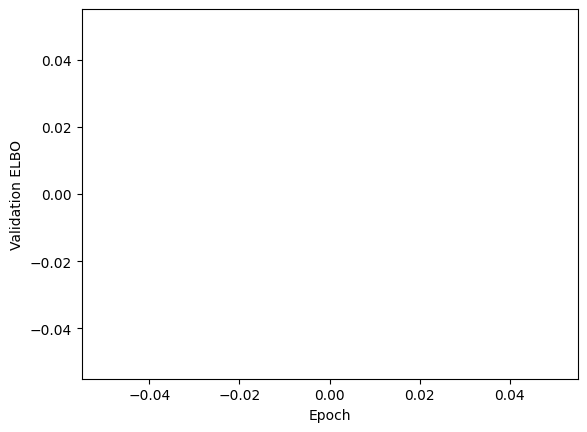

In [58]:
plt.plot(model.history["elbo_validation"].iloc[5:])
plt.xlabel("Epoch")
plt.ylabel("Validation ELBO")
plt.show()

In [60]:
u = model.get_latent_representation()
adata.obsm["u"] = u
sc.pp.neighbors(adata, use_rep="u")
sc.tl.umap(adata, min_dist=0.3)

100%|██████████| 515/515 [00:07<00:00, 66.16it/s] 


In [ ]:
sc.pl.umap(
    adata,
    color=["sample"],
    frameon=False,
    ncols=1,
)